## Stepan-VORONYI-Camp-2026
# Hometask lesson 5:Decision Trees

## Breast cancer dataset

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
cancer = load_breast_cancer()
X, y, labels, features = cancer.data, cancer.target, cancer.target_names, cancer.feature_names
print ('labels:',labels)
print ('features:', features)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

labels: ['malignant' 'benign']
features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [6]:
%pip install graphviz

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Decision Tree

train accuracy= 97.653%
test accuracy= 93.706%


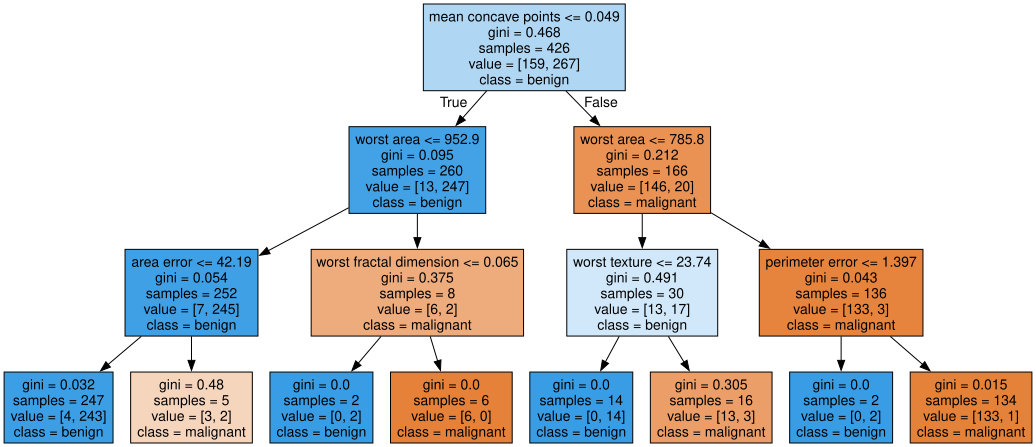

In [14]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import graphviz

# YOUR_CODE. create the classifier and train it 
# START_CODE 
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))
graph_viz = tree.export_graphviz(clf, out_file=None, feature_names=features, class_names=labels, filled = True)
graph = graphviz.Source(graph_viz)
graph # cleanup (bool) – Delete the source file after rendering.

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# YOUR_CODE.  create the classifier and train it 
# START_CODE
clf = RandomForestClassifier(max_depth=3, random_state=0)
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score(X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test, y_test)))

train accuracy= 98.122%
test accuracy= 95.804%


## Gradient Boosting model

In [16]:
from sklearn.ensemble import GradientBoostingClassifier

# YOUR_CODE. create the classifier and train it 
# START_CODE 
clf = GradientBoostingClassifier(max_depth=3,random_state=42)
clf.fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 96.503%


## XGBoost

In [18]:
%pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from xgboost import XGBClassifier

# YOUR_CODE. create the classifier and train it 
# START_CODE 
clf = XGBClassifier(
    n_estimators=100,
    max_depth=3,         
    learning_rate=0.1, 
    use_label_encoder=False, 
    eval_metric='logloss',
    random_state=42
)
clf.fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 98.601%


c:\Users\Stepan\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [22:53:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Additional Tasks
## 1) Binary Classification:
Task: Train an XGBClassifier to predict whether a person's income exceeds $50,000 per year based on census data (age, education, occupation, etc.).

## Load clasification dataset

In [22]:
from sklearn.datasets import fetch_openml
import pandas as pd

adult = fetch_openml(name='adult', version=2, as_frame=True, parser='auto')
df = adult.frame

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## Data preprocessing

In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

categorical_cols = df.select_dtypes(include=['category', 'object']).columns
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_final.drop('class', axis=1)
y = df_final['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Correlation Heatmap

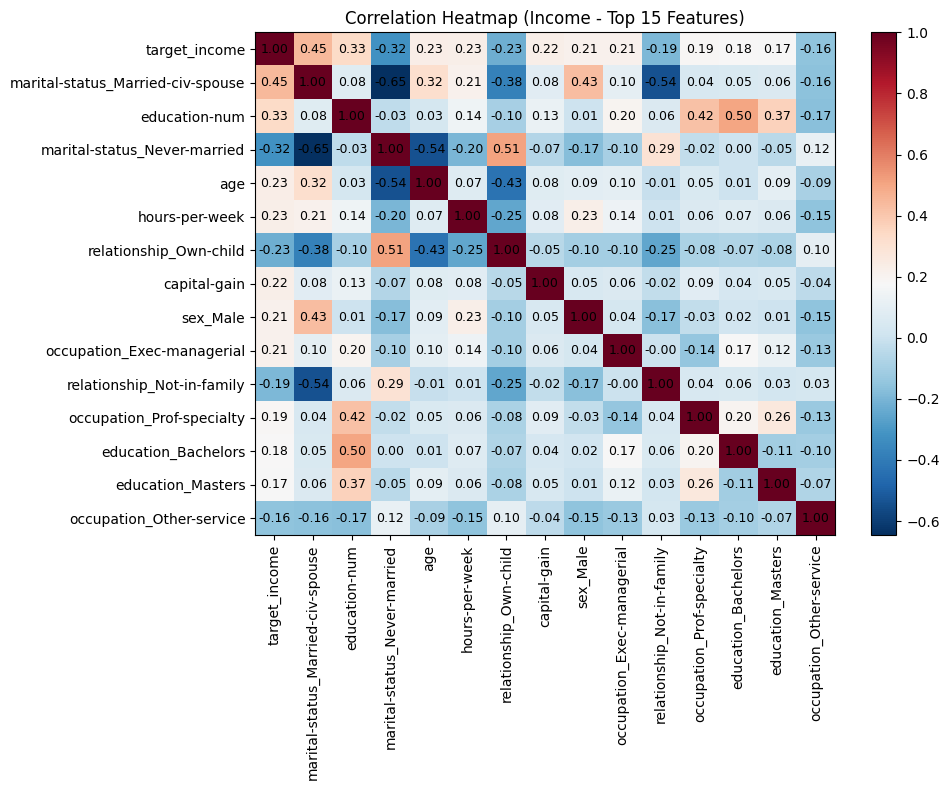

In [24]:
import matplotlib.pyplot as plt
import numpy as np

income_corr_df = X.copy()
income_corr_df['target_income'] = y

top_income_corr = income_corr_df.corr()['target_income'].abs().sort_values(ascending=False).head(15).index
income_corr_matrix = income_corr_df[top_income_corr].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(income_corr_matrix, interpolation='nearest', aspect='auto', cmap='RdBu_r')
plt.colorbar(im)
plt.xticks(range(len(income_corr_matrix.columns)), income_corr_matrix.columns, rotation=90)
plt.yticks(range(len(income_corr_matrix.index)), income_corr_matrix.index)

for i in range(len(income_corr_matrix.columns)):
    for j in range(len(income_corr_matrix.index)):
        plt.text(j, i, f"{income_corr_matrix.iloc[i, j]:.2f}", 
                 ha="center", va="center", color="black", fontsize=9)

plt.title("Correlation Heatmap (Income - Top 15 Features)")
plt.tight_layout()
plt.show()

## XGBoost Classifier

In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clf_income = XGBClassifier(
    n_estimators=100,      
    max_depth=4,            
    learning_rate=0.1,     
    subsample=0.8,          
    colsample_bytree=0.8,   
    random_state=42,        
    eval_metric='logloss'   
)

clf_income.fit(X_train, y_train)
y_pred_income = clf_income.predict(X_test)


train_acc = clf_income.score(X_train, y_train)
test_acc = accuracy_score(y_test, y_pred_income)

## Evaluation 


Accuracy on Train Data: 87.296%
Accuracy on Test Data: 87.389%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      7431
           1       0.81      0.62      0.70      2338

    accuracy                           0.87      9769
   macro avg       0.85      0.79      0.81      9769
weighted avg       0.87      0.87      0.87      9769



<Figure size 800x600 with 0 Axes>

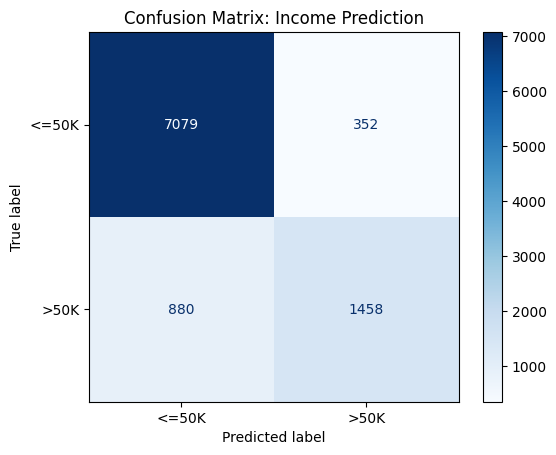

In [28]:
print(f"\nAccuracy on Train Data: {train_acc:.3%}")
print(f"Accuracy on Test Data: {test_acc:.3%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_income))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_income)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Income Prediction")
plt.show()

## Feature importance

<Figure size 1000x800 with 0 Axes>

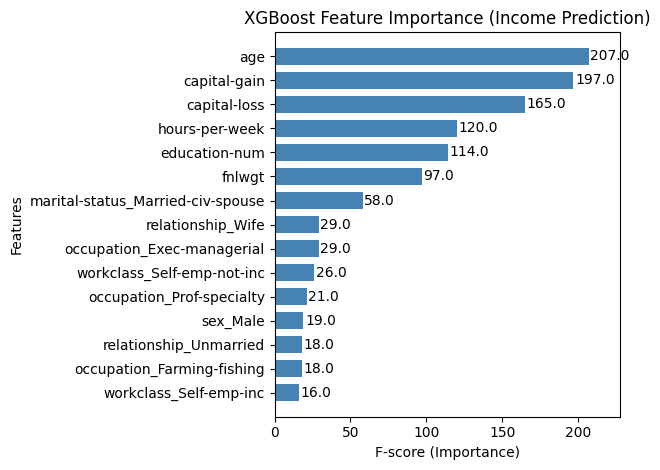

In [29]:
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(clf_income, max_num_features=15, height=0.7, color='steelblue', grid=False)
plt.title("XGBoost Feature Importance (Income Prediction)")
plt.xlabel("F-score (Importance)")
plt.tight_layout()
plt.show()

## 2) Regression:
Task: Train an XGBRegressor to predict the final sale price of houses in Ames, Iowa, based on various features (area, quality, year built).

## Load Dataset

In [30]:
housing = fetch_openml(name="house_prices", as_frame=True, parser='auto')
df_house = housing.frame
df_house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Data Preprocessing

In [31]:
if 'Id' in df_house.columns:
    df_house = df_house.drop('Id', axis=1)

numeric_cols = df_house.select_dtypes(include=['number']).columns
df_house[numeric_cols] = df_house[numeric_cols].fillna(df_house[numeric_cols].median())
categorical_cols = df_house.select_dtypes(include=['object', 'category']).columns
df_house[categorical_cols] = df_house[categorical_cols].fillna('None')

df_house_processed = pd.get_dummies(df_house, columns=categorical_cols, drop_first=True)
X_house = df_house_processed.drop('SalePrice', axis=1)
y_house = df_house_processed['SalePrice']
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

print({X_train_h.shape[1]})

{260}


## Correlation Heatmap

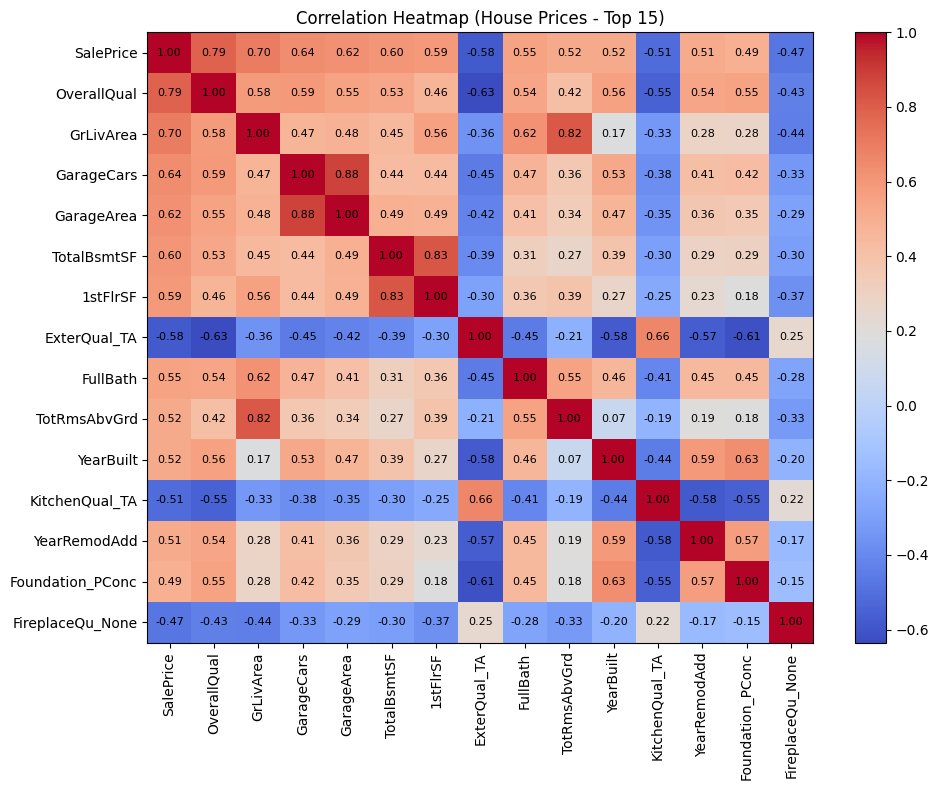

In [32]:
import matplotlib.pyplot as plt

house_corr_df = X_train_h.copy()
house_corr_df['SalePrice'] = y_train_h
top_house_corr = house_corr_df.corr()['SalePrice'].abs().sort_values(ascending=False).head(15).index
house_corr_matrix = house_corr_df[top_house_corr].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(house_corr_matrix, interpolation='nearest', aspect='auto', cmap='coolwarm')
plt.colorbar(im)
plt.xticks(range(len(house_corr_matrix.columns)), house_corr_matrix.columns, rotation=90)
plt.yticks(range(len(house_corr_matrix.index)), house_corr_matrix.index)

for i in range(len(house_corr_matrix.columns)):
    for j in range(len(house_corr_matrix.index)):
        plt.text(j, i, f"{house_corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
        
plt.title("Correlation Heatmap (House Prices - Top 15)")
plt.tight_layout()
plt.show()

## XGBoost Regressor

In [34]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_reg.fit(X_train_h, y_train_h)
print("train score (R^2)= {:.3f}".format(xgb_reg.score(X_train_h, y_train_h)))
print("test score (R^2)= {:.3f}".format(xgb_reg.score(X_test_h, y_test_h)))

train score (R^2)= 0.998
test score (R^2)= 0.915


## Evaluation

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_h = xgb_reg.predict(X_test_h)

print("\nMetrics for Regression:")
print(f"R^2 Score: {r2_score(y_test_h, y_pred_h):.4f}")
print(f"MAE: {mean_absolute_error(y_test_h, y_pred_h):,.2f}")
print(f"MSE: {mean_squared_error(y_test_h, y_pred_h):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_h, y_pred_h)):,.2f}")


Metrics for Regression:
R^2 Score: 0.9154
MAE: 15,191.35
MSE: 649233856.000
RMSE: 25,480.07


## Feature Importance

<Figure size 1000x800 with 0 Axes>

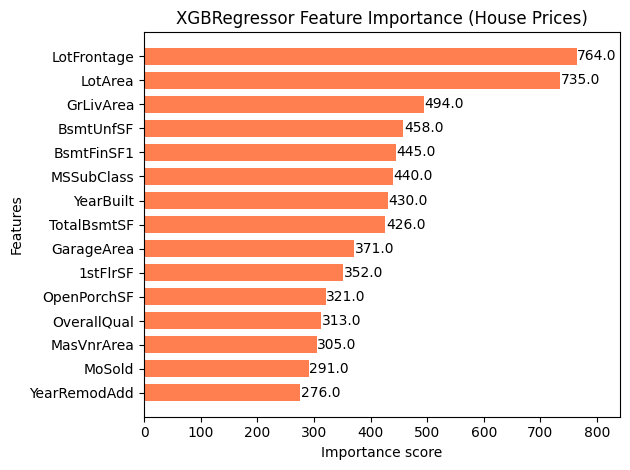

In [37]:
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(xgb_reg, max_num_features=15, height=0.7, color='coral', grid=False)
plt.title("XGBRegressor Feature Importance (House Prices)")
plt.tight_layout()
plt.show()